<a href="https://colab.research.google.com/github/marianaamaya092105-wq/telecom2/blob/main/chyallenge2tele.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

###Librerías

In [19]:
# Importar librerías
import pandas as pd
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
df = pd.read_json(url)

df = pd.json_normalize(pd.read_json(url).to_dict(orient="records"))


###Conocer el dataframe

In [3]:
#mostrar datos básicos
df.head()
# Ver información general del DataFrame
df.info()
# Ver dimensiones (filas, columnas)
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


(7267, 6)

###Ver características de los datos

In [5]:
#conocer los datos
# Ver las primeras filas
df.head()

# Ver las columnas del dataset
print(df.columns)

# Ver tipos de datos de cada columna
print("\nTipos de datos:")
print(df.dtypes)

# Información general del DataFrame
print("\nInformación general:")
df.info()

# Ver cantidad de valores nulos por columna
print("\nValores nulos por columna:")
print(df.isnull().sum())

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

Tipos de datos:
customerID    object
Churn         object
customer      object
phone         object
internet      object
account       object
dtype: object

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB

Valores nulos por columna:
customerID    0
Churn         0
customer      0
phone         0
internet      0
account       0
dtype: int64


In [30]:
##para corregir error del codigo
for col in df.columns:
    if df[col].apply(lambda x: isinstance(x, dict)).any():
        expanded = pd.json_normalize(df[col])
        expanded.columns = [f"{col}_{subcol}" for subcol in expanded.columns]
        df = pd.concat([df.drop(columns=[col]), expanded], axis=1)

In [10]:
# Revisar valores nulos
print("Valores nulos por columna:")
display(df.isnull().sum())

# Revisar filas duplicadas
print("Número de filas duplicadas:")
print(df.duplicated().sum())

# Mostrar filas duplicadas si existen
duplicados = df[df.duplicated()]
display(duplicados)

# Revisar valores únicos en cada columna (para detectar inconsistencias)
print("Valores únicos por columna:")
for col in df.columns:
    print(f"\nColumna: {col}")
    print(df[col].unique())

Valores nulos por columna:


,0
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


Número de filas duplicadas:
0


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total


Valores únicos por columna:

Columna: customerID
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']

Columna: Churn
['No' 'Yes' '']

Columna: customer_gender
['Female' 'Male']

Columna: customer_SeniorCitizen
[0 1]

Columna: customer_Partner
['Yes' 'No']

Columna: customer_Dependents
['Yes' 'No']

Columna: customer_tenure
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]

Columna: phone_PhoneService
['Yes' 'No']

Columna: phone_MultipleLines
['No' 'Yes' 'No phone service']

Columna: internet_InternetService
['DSL' 'Fiber optic' 'No']

Columna: internet_OnlineSecurity
['No' 'Yes' 'No internet service']

Columna: internet_OnlineBackup
['Yes' 'No' 'No internet service']

Columna: internet_DeviceProtection
['No' 'Yes' 'No internet service']

Columna: internet_TechSupport
['Yes' 'No' 'N

###Manejar características encontradas

In [13]:
# Eliminar filas duplicadas
df = df.drop_duplicates()

# Limpiar espacios en columnas de texto
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()


# Reemplazar valores vacíos por NaN
df = df.replace("", pd.NA)

df.head()


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

###Añadir columna

In [20]:
# Crear la columna Cuentas_Diarias usando la facturación mensual
df["Cuentas_Diarias"] = pd.to_numeric(df["account.Charges.Monthly"], errors="coerce") / 30

# Verificar que se creó correctamente
df[["account.Charges.Monthly", "Cuentas_Diarias"]].head()


,account.Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


###Estandarizar los datos

In [22]:
#Convertir valores binarios

map_binario = {
    "yes": 1, "no": 0,
    "sí": 1, "si": 1, "no": 0
}

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.lower().replace(map_binario)


# Renobrar columnas

df = df.rename(columns={
    "customer.gender": "Genero",
    "customer.SeniorCitizen": "Adulto_Mayor",
    "customer.Partner": "Tiene_Pareja",
    "customer.Dependents": "Dependientes",
    "customer.tenure": "Meses_Cliente",
    "phone.PhoneService": "Servicio_Telefono",
    "internet.InternetService": "Servicio_Internet",
    "account.Contract": "Tipo_Contrato",
    "account.PaymentMethod": "Metodo_Pago",
    "account.Charges.Monthly": "Cargo_Mensual",
    "account.Charges.Total": "Cargo_Total",
    "Churn": "Evasion"
})


# Convertir columnas numéricas a tipo numerico

df["Cargo_Mensual"] = pd.to_numeric(df["Cargo_Mensual"], errors="coerce")
df["Cargo_Total"] = pd.to_numeric(df["Cargo_Total"], errors="coerce")


df.head()

,customerID,Evasion,Genero,Adulto_Mayor,Tiene_Pareja,Dependientes,Meses_Cliente,Servicio_Telefono,phone.MultipleLines,Servicio_Internet,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,Tipo_Contrato,account.PaperlessBilling,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0002-orfbo,NaN,female,0,1,1,9,1,NaN,dsl,...,NaN,NaN,NaN,NaN,one year,1,mailed check,65.6,593.30,2.186667
1,0003-mknfe,NaN,male,0,0,0,9,1,NaN,dsl,...,NaN,NaN,NaN,NaN,month-to-month,0,mailed check,59.9,542.40,1.996667
2,0004-tlhlj,NaN,male,0,0,0,4,1,NaN,fiber optic,...,NaN,NaN,NaN,NaN,month-to-month,1,electronic check,73.9,280.85,2.463333
3,0011-igkff,NaN,male,1,1,0,13,1,NaN,fiber optic,...,NaN,NaN,NaN,NaN,month-to-month,1,electronic check,98.0,1237.85,3.266667
4,0013-exchz,NaN,female,1,1,0,3,1,NaN,fiber optic,...,NaN,NaN,NaN,NaN,month-to-month,1,mailed check,83.9,267.40,2.796667


###Media mediana, moda

In [23]:
# Estadísticas descriptivas de las columnas numéricas
df.describe()

,Adulto_Mayor,Tiene_Pareja,Dependientes,Meses_Cliente,Servicio_Telefono,account.PaperlessBilling,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7256.000000,7267.000000
mean,0.162653,0.484106,0.300124,32.346498,0.902711,0.593230,64.720098,2280.634213,2.157337
std,0.369074,0.499782,0.458343,24.571773,0.296371,0.491265,30.129572,2268.632997,1.004319
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.425000,400.225000,1.180833
50%,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1391.000000,2.343333
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.875000,3785.300000,2.995833
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


El análisis descriptivo muestra que los clientes tienen en promedio 32 meses de permanencia en la empresa, con una mediana de 29 meses, lo que indica que la mayoría lleva entre 2 y 3 años usando el servicio. El cargo mensual promedio es de aproximadamente 64.7, aunque presenta una alta variabilidad (desviación estándar de 30.1), lo que sugiere la existencia de diferentes planes o niveles de servicio. En cuanto al cargo total, el promedio es de 2280.6, con una dispersión alta, lo cual se relaciona con el tiempo que cada cliente ha permanecido en la compañía. Además, la mayoría de los clientes tiene servicio telefónico (90%) y utiliza facturación electrónica (59%), mientras que una menor proporción corresponde a adultos mayores (16%) o clientes con dependientes (30%), lo que permite identificar características generales del perfil de los usuarios de Telecom X.

###Distribución de evasión

[nan '']
Evasion
nan    7043
        224
Name: count, dtype: int64


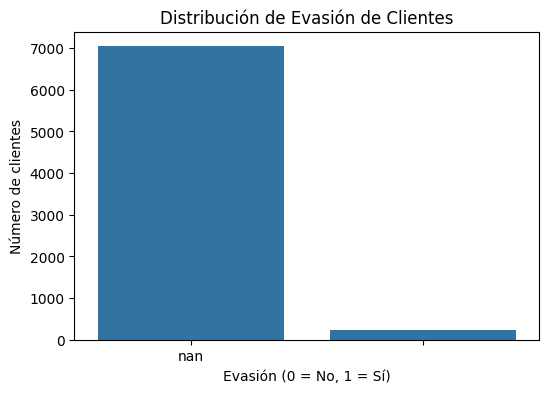

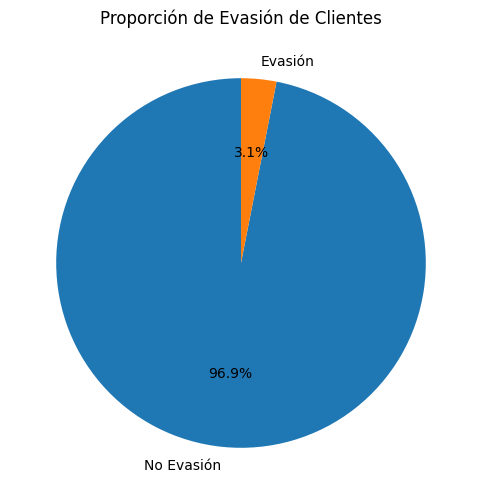

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ver valores originales de la columna
print(df["Evasion"].unique())

# Estandarizar texto
df["Evasion"] = df["Evasion"].astype(str).str.strip().str.lower()

# Convertir a binario
df["Evasion"] = df["Evasion"].replace({
    "yes": 1,
    "no": 0
})

# Verificar distribución
print(df["Evasion"].value_counts())

# Gráfico de barras
plt.figure(figsize=(6,4))
sns.countplot(x="Evasion", data=df)
plt.title("Distribución de Evasión de Clientes")
plt.xlabel("Evasión (0 = No, 1 = Sí)")
plt.ylabel("Número de clientes")
plt.show()

# Gráfico de proporción
churn_counts = df["Evasion"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(churn_counts, labels=["No Evasión", "Evasión"], autopct='%1.1f%%', startangle=90)
plt.title("Proporción de Evasión de Clientes")
plt.show()

###Recuento de evasión por variables categóricas

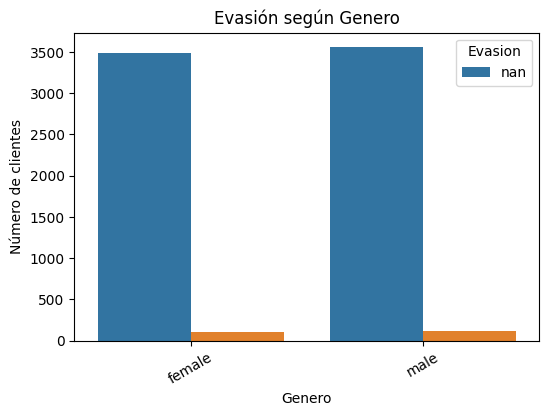

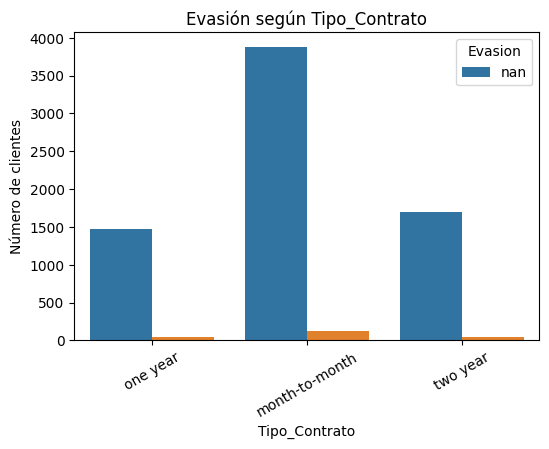

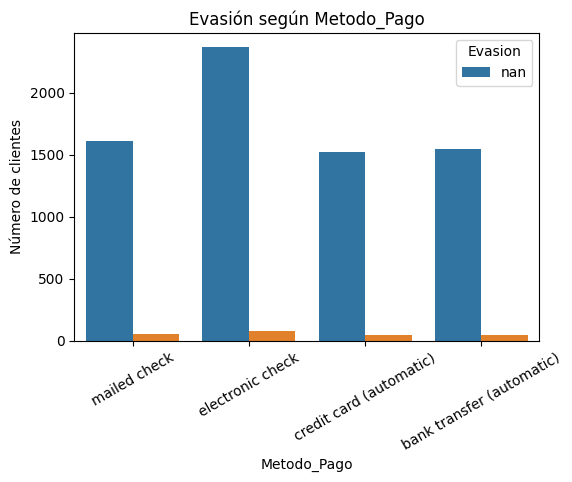

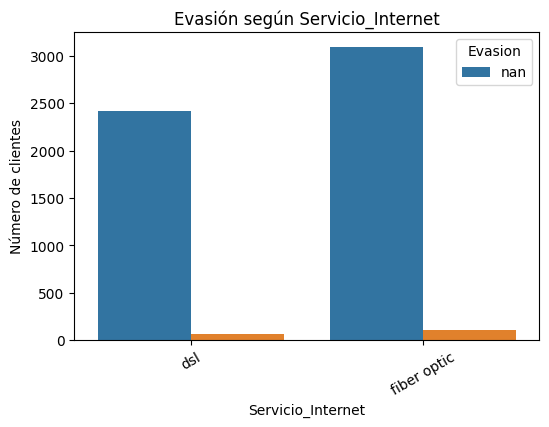

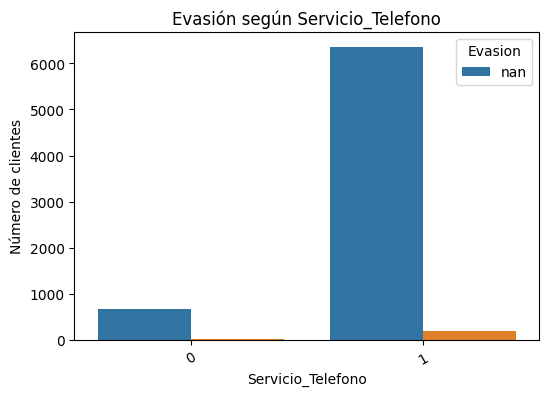

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de variables categóricas importantes
categorical_cols = [
    "Genero",
    "Tipo_Contrato",
    "Metodo_Pago",
    "Servicio_Internet",
    "Servicio_Telefono"
]

# Crear gráficos de evasión por cada variable categórica
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue="Evasion", data=df)
    plt.title(f"Evasión según {col}")
    plt.xlabel(col)
    plt.ylabel("Número de clientes")
    plt.xticks(rotation=30)
    plt.show()

###Conteo de evasión por variables numéricas

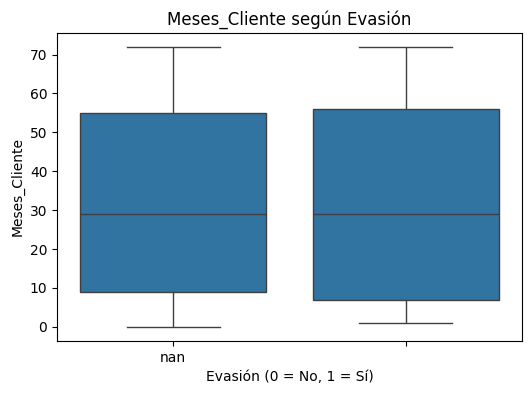

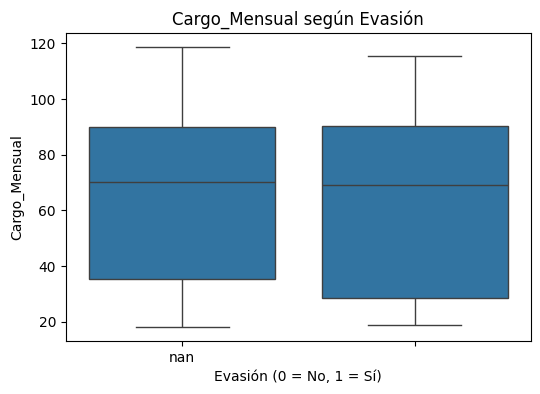

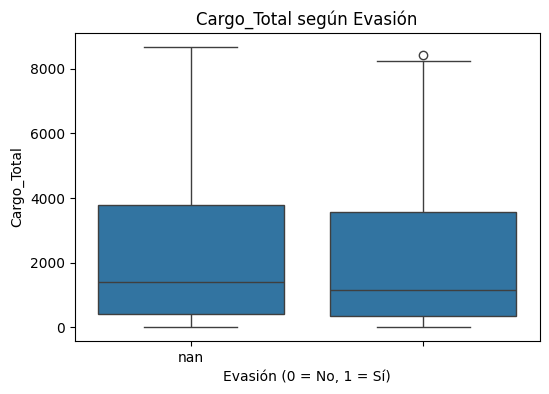

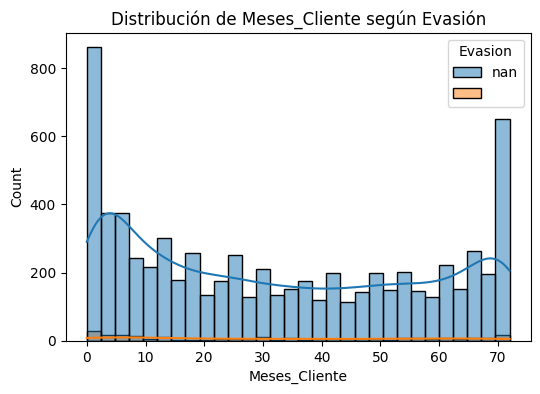

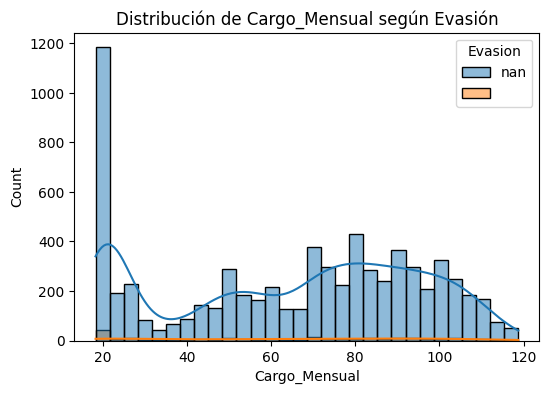

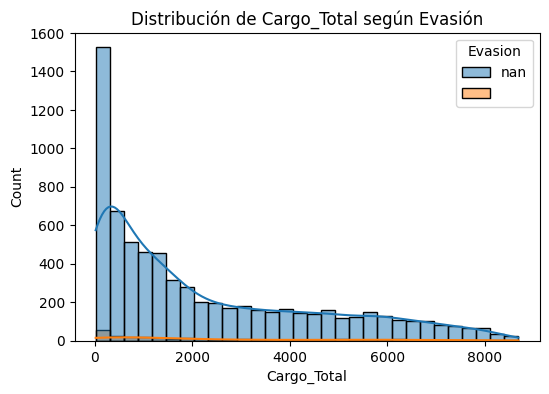

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variables numéricas importantes
numeric_cols = ["Meses_Cliente", "Cargo_Mensual", "Cargo_Total"]

# Boxplots para comparar distribución según evasión
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Evasion", y=col, data=df)
    plt.title(f"{col} según Evasión")
    plt.xlabel("Evasión (0 = No, 1 = Sí)")
    plt.ylabel(col)
    plt.show()

# Histogramas para ver la distribución
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, hue="Evasion", bins=30, kde=True)
    plt.title(f"Distribución de {col} según Evasión")
    plt.show()

#📄Informe final

##Introducción


El presente análisis tuvo como objetivo explorar la evasión de clientes en  Telecom X, es decir, entender por qué algunos clientes cancelan el servicio mientras otros permanecen en la empresa. Este problema es importante porque la pérdida de clientes afecta directamente los ingresos y la estabilidad del negocio. A partir de los datos entregados, se realizó un proceso de preparación, limpieza y análisis para identificar patrones relacionados con el tiempo de permanencia, los cargos facturados, el tipo de contrato, el método de pago y otros aspectos del perfil del cliente. La intención de este trabajo fue generar información útil que pueda servir de base para futuras decisiones estratégicas y para el desarrollo de modelos predictivos de churn.

##Sobre la limpieza y tratamiento de datos

La base de datos fue cargada desde una fuente en formato JSON, por lo que al inicio fue necesario revisar su estructura para identificar cómo estaban organizados los datos. En una primera exploración se observó que el archivo tenía 7267 registros y 6 columnas principales, pero varias de ellas contenían información agrupada en formato anidado, especialmente en los apartados de cliente, teléfono, internet y cuenta. Por esta razón, fue necesario desglosar esas columnas para convertir la información en un formato más manejable y adecuado para el análisis.

Después de expandir la información, se revisaron los tipos de datos, la presencia de valores nulos y la consistencia de las variables. En esta revisión se encontró que, aunque las columnas principales no mostraban valores nulos al inicio, algunas variables internas como el cargo total sí presentaban diferencias en el número de registros válidos. También se trabajó en la estandarización de nombres de columnas para que fueran más claros y fáciles de interpretar. Además, se creó una nueva variable llamada Cuentas_Diarias, calculada a partir del cargo mensual dividido entre 30, con el fin de tener una referencia diaria del gasto de cada cliente.

Durante la preparación también se transformaron algunas variables de respuesta binaria, como las relacionadas con si el cliente tiene pareja, dependientes o servicio telefónico, para facilitar su lectura y análisis. Sin embargo, en la variable de evasión se observa todavía un problema de transformación, ya que en los gráficos finales aparece la categoría nan junto con la evasión, lo que sugiere que una parte de los valores no fue convertida correctamente. Esto no impide observar tendencias generales, pero sí debe corregirse antes de considerar el análisis como definitivo.

##Análisis exploratorio de datos

En el análisis descriptivo general se observó que los clientes tienen en promedio 32.35 meses de permanencia en la empresa, con una mediana de 29 meses, lo que indica que una gran parte de los usuarios lleva entre dos y tres años con el servicio. También se identificó que el cargo mensual promedio es de 64.72, mientras que el cargo total promedio es de 2280.63. La diferencia amplia entre los valores mínimos y máximos, así como la desviación estándar relativamente alta, muestra que existen perfiles de clientes muy distintos: algunos con servicios básicos y otros con planes más amplios o de mayor costo.

En cuanto a las características generales de la base, se encontró que la mayoría de los clientes tiene servicio telefónico, que más de la mitad usa facturación sin papel, y que una parte menor corresponde a adultos mayores o clientes con dependientes. Estos datos ayudan a construir un perfil general de la cartera de clientes y permiten entender mejor qué tipo de usuarios predominan dentro de la empresa.

Respecto a la variable de evasión, los gráficos muestran una distribución muy desbalanceada, donde la mayor parte de los registros quedó agrupada como nan y una pequeña parte como evasión. Visualmente, esto hace parecer que la evasión es cercana al 3.1%, pero ese resultado no debe interpretarse como definitivo, porque la presencia de la categoría nan indica que los valores de “sí” y “no” no fueron convertidos correctamente en todos los casos. Aun así, el gráfico sí permite concluir que la columna de evasión necesita una corrección adicional antes de usarla para cálculos finales más precisos.

En el análisis por variables categóricas se revisó la evasión según género, tipo de contrato, método de pago, servicio de internet y servicio telefónico. En términos generales, no se observan diferencias muy marcadas por género, ya que hombres y mujeres presentan una distribución relativamente parecida. En cambio, sí se ven patrones más interesantes en el tipo de contrato y en el método de pago. Los contratos mes a mes concentran un mayor número de casos asociados a evasión, lo que sugiere que los clientes con menor compromiso contractual tienen mayor probabilidad de cancelar el servicio. Asimismo, el método de pago por electronic check parece reunir más casos problemáticos que otras formas de pago automáticas, lo que puede estar relacionado con un perfil de cliente menos estable o con menor fidelización.

En relación con el servicio de internet, se observa una mayor concentración de clientes en fibra óptica y también una mayor presencia de evasión en comparación con DSL. Esto puede indicar que, aunque la fibra óptica es un servicio más moderno y demandado, también puede estar asociada a clientes más exigentes o a planes de mayor costo, lo que podría aumentar la probabilidad de cancelación. Por otro lado, el servicio telefónico no parece ser, por sí solo, un factor tan determinante, ya que la mayoría de los clientes lo tiene y las diferencias visuales en evasión no son tan fuertes como en otras variables.

En el análisis de variables numéricas se compararon el tiempo de permanencia, el cargo mensual y el cargo total entre clientes que cancelaron y quienes no lo hicieron. Los diagramas de caja y las distribuciones muestran que el tiempo de permanencia es una variable importante, ya que los clientes con menos meses en la empresa parecen estar más expuestos a abandonar el servicio. Esto es coherente con la idea de que los primeros meses son una etapa crítica en la relación con el cliente. También se observa que el cargo mensual y el cargo total presentan una alta dispersión, lo que indica que el gasto no es uniforme entre los usuarios. Aunque por la inconsistencia en la variable de evasión no se puede afirmar con total seguridad qué grupo gasta más, sí se aprecia que los cargos altos y los planes más costosos podrían estar relacionados con una mayor sensibilidad al abandono.

##Conclusiones e insights

El análisis permitió identificar que la base de clientes de Telecom X es diversa en cuanto a antigüedad, nivel de gasto y tipo de servicio contratado. Los clientes permanecen, en promedio, poco más de dos años y medio en la empresa, pero hay diferencias grandes entre quienes llevan pocos meses y quienes tienen una relación de largo plazo. Esta variación es importante porque el tiempo de permanencia parece ser una de las variables más asociadas con la evasión.

También se encontró que el tipo de contrato mes a mes sobresale como uno de los perfiles con mayor riesgo, lo que tiene sentido porque estos clientes no tienen un compromiso de permanencia prolongado. De forma similar, el método de pago electrónico mostró señales de mayor asociación con la evasión, mientras que los contratos de uno o dos años parecen estar vinculados con una mayor estabilidad. En cuanto a los servicios, la fibra óptica reúne una mayor cantidad de clientes y también parece concentrar más cancelaciones que otras opciones, por lo que sería útil revisar con más detalle la experiencia de esos usuarios.

Un hallazgo importante del proceso fue detectar que la variable de evasión todavía necesita una mejor estandarización, ya que una gran parte de los registros quedó como nan. Este punto es relevante porque afecta la lectura exacta de las proporciones y limita la precisión de algunas conclusiones. Sin embargo, el trabajo sí permitió identificar tendencias útiles y, sobre todo, dejar claro qué variables merecen mayor atención en una siguiente etapa de análisis más precisa.

##Recomendaciones

A partir de los resultados obtenidos, una recomendación clave es fortalecer las estrategias de retención en los primeros meses del cliente, ya que esta etapa parece ser la más sensible frente a la cancelación. La empresa podría implementar acompañamiento inicial, seguimiento más cercano y beneficios de permanencia temprana para reducir la pérdida de usuarios nuevos.

También sería conveniente diseñar acciones específicas para los clientes con contrato mes a mes, ya que este grupo muestra mayor vulnerabilidad. Por ejemplo, se pueden ofrecer incentivos para migrar a contratos de mayor duración, descuentos por permanencia o beneficios adicionales por renovación. De la misma manera, conviene revisar los casos asociados al pago por electronic check, ya que este método parece concentrar más clientes con tendencia a cancelar.

En el caso del servicio de fibra óptica, se recomienda profundizar en la experiencia de estos clientes, revisando si existen inconformidades relacionadas con precio, calidad del servicio o expectativas no cumplidas. Si bien este grupo representa una parte importante de la cartera, también podría estar concentrando un riesgo mayor de evasión. Finalmente, antes de continuar con modelos predictivos o decisiones más avanzadas, es indispensable corregir completamente la variable de evasión, para asegurar que el análisis refleje con exactitud cuántos clientes cancelan y cuáles son sus características reales.